**Mall customer segmentation**

# Import Librarie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

**Load dataset**

In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')

print("First 5 Rows")
print(df.head())

First 5 Rows
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


# DATA INFORMATION

In [3]:
print("\nDataset Information")
print(df.info())

print("\nDataset Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Dataset Shape
(200, 5)

Missing Values
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   

# EXPLORATORY DATA ANALYSIS

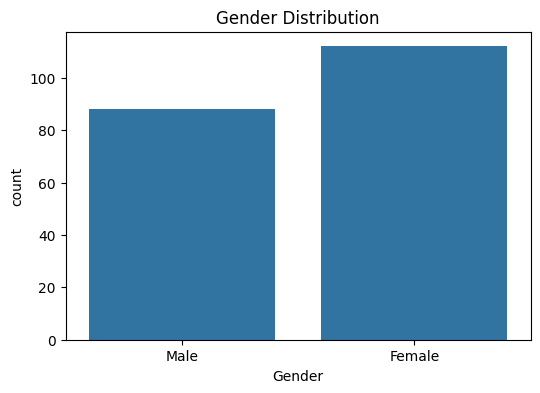

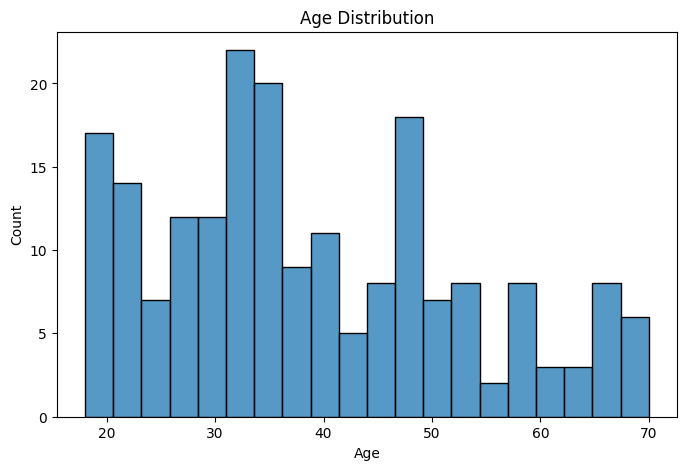

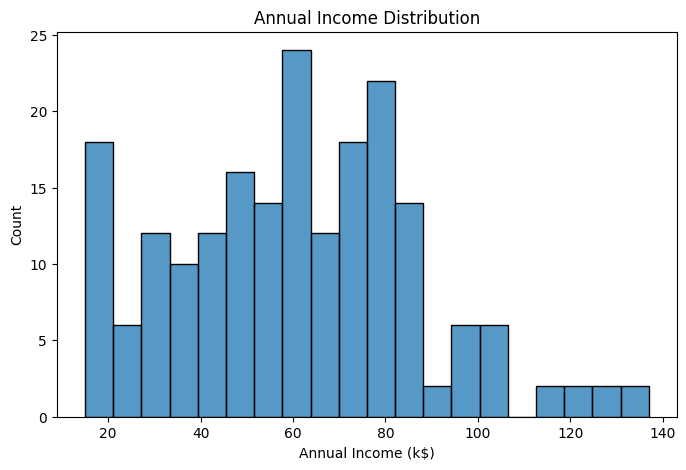

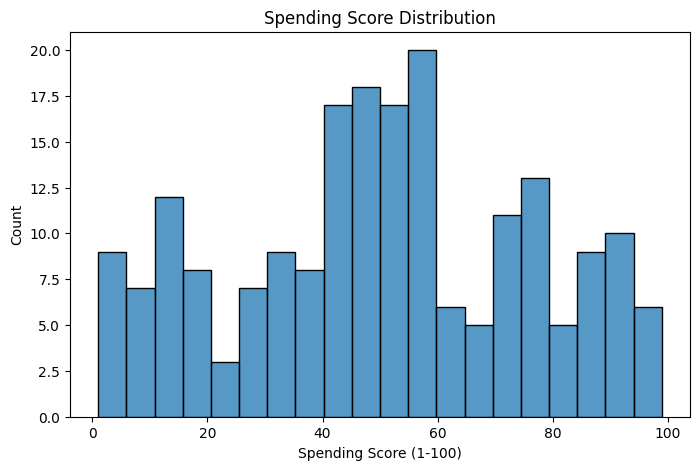

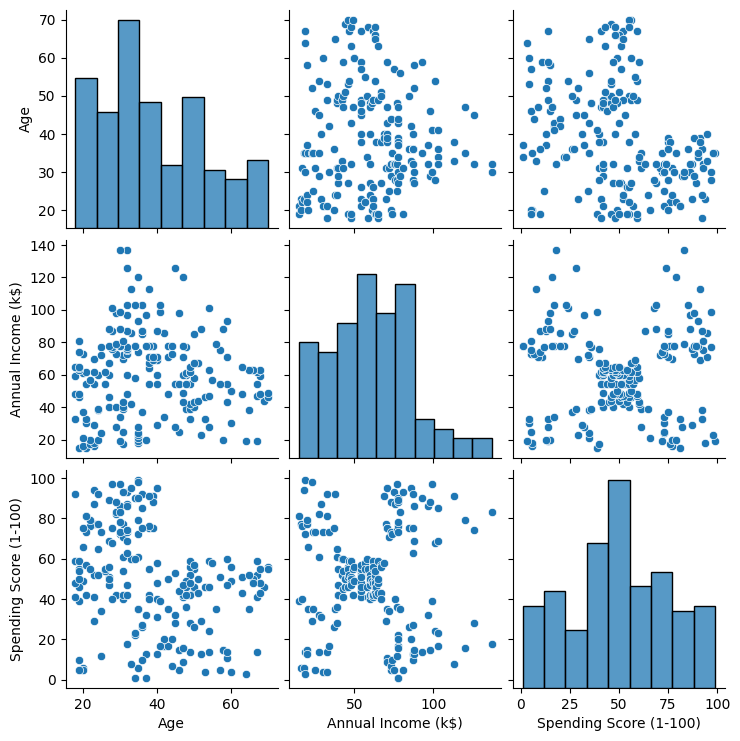

In [4]:
# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

# Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20)
plt.title("Annual Income Distribution")
plt.show()

# Spending Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=20)
plt.title("Spending Score Distribution")
plt.show()

# Pair Plot
sns.pairplot(
    df[['Age',
        'Annual Income (k$)',
        'Spending Score (1-100)']]
)
plt.show()

FEATURE SELECTION

In [5]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']].values

# ELBOW METHOD

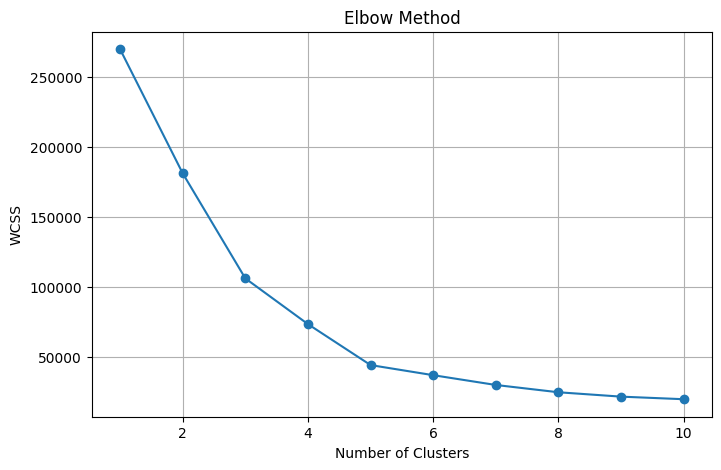

In [6]:

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# K-MEANS CLUSTERING



In [9]:

kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X)

# ADD CLUSTER COLUMN

In [10]:

df['Cluster'] = y_kmeans

print("\nCluster Counts")
print(df['Cluster'].value_counts())


Cluster Counts
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


# CLUSTER VISUALIZATION

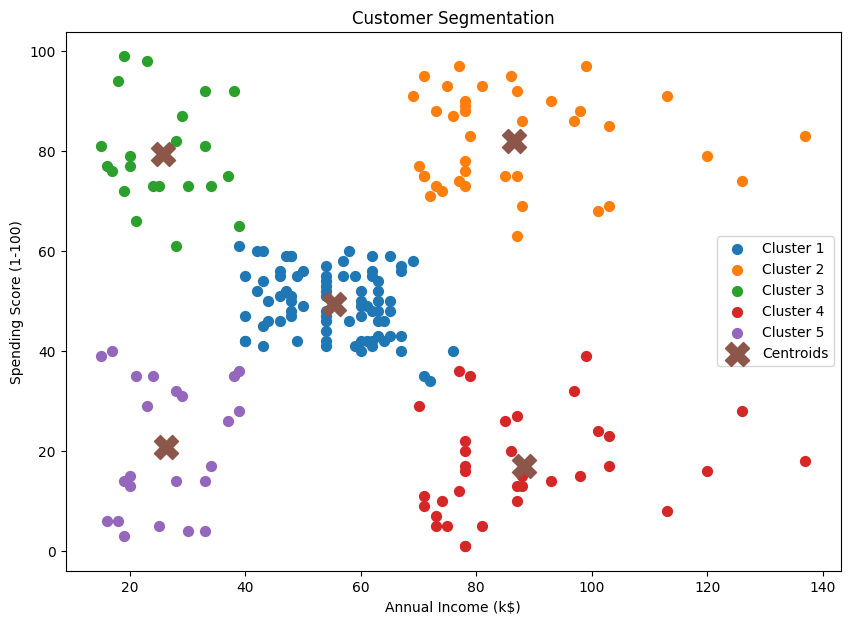

In [11]:
plt.figure(figsize=(10,7))

plt.scatter(
    X[y_kmeans==0,0],
    X[y_kmeans==0,1],
    s=50,
    label='Cluster 1'
)

plt.scatter(
    X[y_kmeans==1,0],
    X[y_kmeans==1,1],
    s=50,
    label='Cluster 2'
)

plt.scatter(
    X[y_kmeans==2,0],
    X[y_kmeans==2,1],
    s=50,
    label='Cluster 3'
)

plt.scatter(
    X[y_kmeans==3,0],
    X[y_kmeans==3,1],
    s=50,
    label='Cluster 4'
)

plt.scatter(
    X[y_kmeans==4,0],
    X[y_kmeans==4,1],
    s=50,
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


# CLUSTER ANALYSIS

In [12]:
cluster_summary = df.groupby('Cluster').mean(
    numeric_only=True
)

print("\nCluster Summary")
print(cluster_summary)

# ==========================================
# SAVE RESULTS
# ==========================================

df.to_csv(
    'customer_segmentation_results.csv',
    index=False
)

print("\nResults saved successfully!")


Cluster Summary
         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043

Results saved successfully!
